In [168]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [169]:
filepath='car.data'

In [170]:
def prepare_dataset(file_path):
    df = pd.read_csv(file_path , header = None)
    df.columns = ['buying' , 'maint' , 'doors' , 'persons' , 'lug_boot' , 'safety' , 'car_acceptibility']
    target_attribute = df.columns[-1]
    attributes = list(df.columns[:-1])

    return df , target_attribute , attributes

In [171]:
car_data , target , attributes = prepare_dataset(filepath)

In [172]:
target

'car_acceptibility'

In [173]:
attributes

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

In [174]:
car_data.shape

(1728, 7)

In [175]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying             1728 non-null   object
 1   maint              1728 non-null   object
 2   doors              1728 non-null   object
 3   persons            1728 non-null   object
 4   lug_boot           1728 non-null   object
 5   safety             1728 non-null   object
 6   car_acceptibility  1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [176]:
car_data.head()

,buying,maint,doors,persons,lug_boot,safety,car_acceptibility
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [177]:
clf0 = DecisionTreeClassifier() 

In [178]:
x = car_data[attributes]

In [179]:
y = car_data[target]

In [180]:
x = pd.get_dummies(x)

In [181]:
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.4,random_state=42,stratify=y)
x_val,x_test,y_val,y_test = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

In [182]:
x_train.shape

(1036, 21)

In [183]:
x_test.shape

(346, 21)

In [184]:
x_val.shape

(346, 21)

In [185]:
y_train.shape

(1036,)

In [186]:
y_test.shape

(346,)

In [187]:
y_val.shape

(346,)

In [188]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    random_state=42
)

In [189]:
clf.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [190]:
train_acc = clf.score(x_train,y_train)
train_acc

0.8976833976833977

In [191]:
val_acc = clf.score(x_val,y_val)
val_acc

0.869942196531792

In [192]:
test_acc = clf.score(x_test,y_test)
test_acc

0.861271676300578

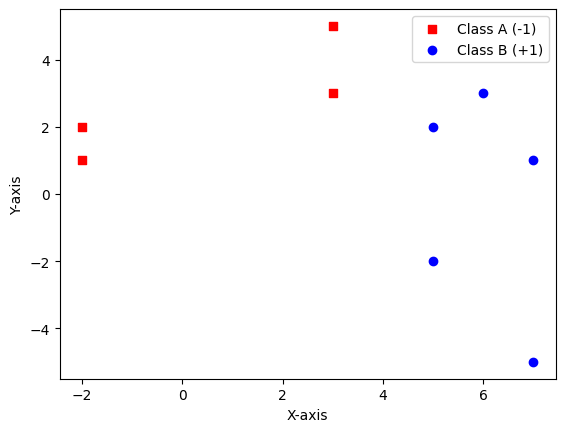

In [3]:
#class - A (-1)
import matplotlib.pyplot as plt
xa = [-2,-2,3,3]
ya = [2,1,3,5]
#class - B (+1)
xb = [5,7,7,5,6]
yb = [-2,1,-5,2,3]

plt.scatter(xa,ya,label='Class A (-1)',color = 'red',marker='s')
plt.scatter(xb,yb,label = 'Class B (+1)',color='blue',marker = 'o')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()